# cGAN Training Notebook — Adaptive Difficulty Rogue

This notebook restructures the training pipeline into clear phases so failures appear where they actually happen.

**Output artifacts:** `generator.pt`, `loot_generator.pt`, `classifier.pt`, `scaler.json`, `training_curve.png`, and `model_runtime.py`.

**Important:** `torch.compile()` is intentionally disabled by default. The previous crash came from TorchInductor requiring a working Triton installation. Training does not require Triton.

In [1]:
# ============================================================
# Phase 0 — Configuration
# ============================================================

from pathlib import Path

CSV_PATH = Path("runs.csv")        # Change this if your CSV has another path
OUT_DIR = Path("models")           # Where artifacts will be saved

EPOCHS = 150
BATCH_SIZE = 32
LR = 2e-4
NOISE_DIM = 16

# Device: "auto", "cuda", "cpu", or "mps"
DEVICE_MODE = "auto"

# On Windows, leave this False. torch.compile can trigger TritonMissing.
ENABLE_TORCH_COMPILE = False

# DataLoader workers. On Windows/Jupyter, 0 is safer for debugging.
# Once everything works, you can try 2 or 4.
NUM_WORKERS = 0

RANDOM_SEED = 42

In [2]:
# ============================================================
# Phase 1 — Imports and reproducibility
# ============================================================

import os
import sys
import csv
import json
import math
import random
import platform
from typing import List, Tuple, Optional
from collections import Counter

import numpy as np
import pandas as pd

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader

import matplotlib.pyplot as plt

random.seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)
torch.manual_seed(RANDOM_SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed_all(RANDOM_SEED)
    torch.set_float32_matmul_precision("high")

print("Python:", sys.version)
print("Platform:", platform.platform())
print("PyTorch:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())
if torch.cuda.is_available():
    print("CUDA device:", torch.cuda.get_device_name(0))
    print("VRAM GB:", round(torch.cuda.get_device_properties(0).total_memory / 1024**3, 2))

Python: 3.12.10 (tags/v3.12.10:0cc8128, Apr  8 2025, 12:21:36) [MSC v.1943 64 bit (AMD64)]
Platform: Windows-11-10.0.26200-SP0
PyTorch: 2.8.0+cu129
CUDA available: True
CUDA device: NVIDIA GeForce RTX 5070 Laptop GPU
VRAM GB: 7.96


In [3]:
# ============================================================
# Phase 2 — Device selection
# ============================================================

def resolve_device(device_str: str) -> torch.device:
    if device_str != "auto":
        d = torch.device(device_str)
        print(f"Device: {d}  (explicit)")
        return d

    if torch.cuda.is_available():
        d = torch.device("cuda")
        name = torch.cuda.get_device_name(0)
        mem = torch.cuda.get_device_properties(0).total_memory / 1024**3
        print(f"Device: {d}  ({name}, {mem:.1f} GB VRAM)  [auto-selected]")
        return d

    if getattr(torch.backends, "mps", None) and torch.backends.mps.is_available():
        d = torch.device("mps")
        print(f"Device: {d}  (Apple Silicon)  [auto-selected]")
        return d

    d = torch.device("cpu")
    print(f"Device: {d}  (no GPU found)  [auto-selected]")
    return d

DEVICE = resolve_device(DEVICE_MODE)
USE_CUDA = DEVICE.type == "cuda"
USE_AMP = USE_CUDA
print("Mixed precision AMP:", USE_AMP)

Device: cuda  (NVIDIA GeForce RTX 5070 Laptop GPU, 8.0 GB VRAM)  [auto-selected]
Mixed precision AMP: True


In [4]:
# ============================================================
# Phase 3 — Raw CSV audit
# ============================================================

assert CSV_PATH.exists(), f"CSV not found: {CSV_PATH.resolve()}"

df = pd.read_csv(CSV_PATH)
print("Rows:", len(df))
print("Columns:", list(df.columns))
display(df.head())

required_cols = [
    "run_id", "melee_kills", "magic_kills", "melee_hits", "magic_hits",
    "damage_taken", "damage_dealt", "deaths", "time_alive",
    "enemy_hp_mult", "enemy_dmg_mult", "enemy_speed_mult", "spawn_count"
]
missing = [c for c in required_cols if c not in df.columns]
assert not missing, f"Missing required columns: {missing}"

print("Duplicate full rows:", int(df.duplicated().sum()))
print("Duplicate run_id count:", int(df["run_id"].duplicated().sum()))
print("Nulls per required column:")
display(df[required_cols].isna().sum().to_frame("null_count"))

Rows: 16459
Columns: ['run_id', 'melee_kills', 'magic_kills', 'melee_hits', 'magic_hits', 'damage_taken', 'damage_dealt', 'deaths', 'time_alive', 'weapon', 'spell', 'boots', 'armor', 'enemy_hp_mult', 'enemy_dmg_mult', 'enemy_speed_mult', 'spawn_count', 'heal_on_kill_base']


,run_id,melee_kills,magic_kills,melee_hits,magic_hits,damage_taken,damage_dealt,deaths,time_alive,weapon,spell,boots,armor,enemy_hp_mult,enemy_dmg_mult,enemy_speed_mult,spawn_count,heal_on_kill_base
0,run_52193,0,0,3,0,105.0,42.0,1,8.337,Hatchet,Hex Spike,Sprint Greaves,Chain Shirt,1.0,1.0,1.0,6,8
1,run_52193,0,0,3,0,105.0,42.0,1,8.337,Hatchet,Hex Spike,Sprint Greaves,Chain Shirt,1.0,1.0,1.0,6,8
2,run_92088,0,0,0,2,104.0,16.0,1,17.396,Rapier,Ice Needle,Voidstep Treads,Blood Harness,1.0,1.0,1.0,6,8
3,run_92088,0,0,0,2,104.0,16.0,1,17.396,Rapier,Ice Needle,Voidstep Treads,Blood Harness,1.0,1.0,1.0,6,8
4,run_38714,0,0,0,0,104.0,0.0,1,2.367,Rusty Blade,Hex Spike,Leather Boots,Blood Harness,1.0,1.0,1.0,6,8


Duplicate full rows: 18
Duplicate run_id count: 332
Nulls per required column:


,null_count
run_id,0
melee_kills,0
magic_kills,0
melee_hits,0
magic_hits,0
damage_taken,0
damage_dealt,0
deaths,0
time_alive,0
enemy_hp_mult,0


Source distribution:


,count
run_id,
bot,16422
player_or_real_seed,37


Style distribution:


,count
run_id,
bot_tank,3325
bot_reckless,3322
bot_magic_sniper,3309
bot_melee_aggressive,3303
bot_hybrid,3163
player_or_real_seed,37


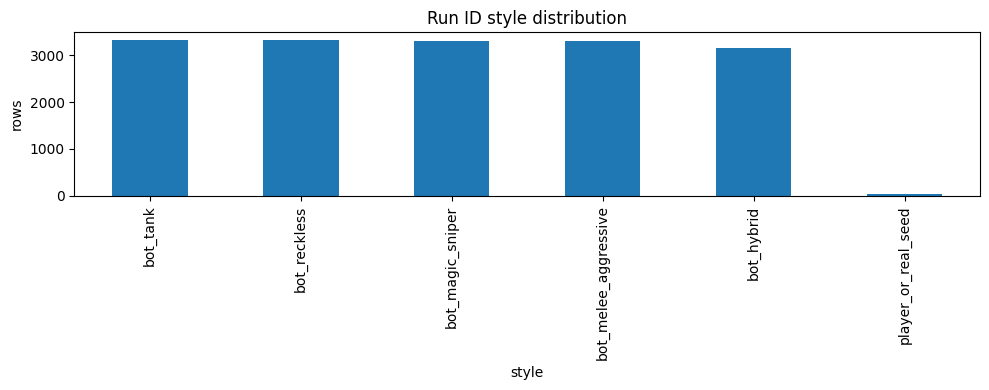

In [5]:
# ============================================================
# Phase 4 — Dataset distribution audit
# ============================================================

def run_id_source(run_id: str) -> str:
    rid = str(run_id).lower()
    if rid.startswith("bot_"):
        return "bot"
    if rid.startswith("run_"):
        return "player_or_real_seed"
    return "unknown"

def run_id_style(run_id: str) -> str:
    rid = str(run_id).lower()
    if rid.startswith("bot_magic_sniper"):
        return "bot_magic_sniper"
    if rid.startswith("bot_reckless"):
        return "bot_reckless"
    if rid.startswith("bot_melee_aggressive"):
        return "bot_melee_aggressive"
    if rid.startswith("bot_tank"):
        return "bot_tank"
    if rid.startswith("bot_hybrid"):
        return "bot_hybrid"
    if rid.startswith("run_"):
        return "player_or_real_seed"
    return "unknown"

source_counts = df["run_id"].apply(run_id_source).value_counts()
style_counts = df["run_id"].apply(run_id_style).value_counts()

print("Source distribution:")
display(source_counts.to_frame("count"))
print("Style distribution:")
display(style_counts.to_frame("count"))

ax = style_counts.plot(kind="bar", title="Run ID style distribution", figsize=(10, 4))
ax.set_xlabel("style")
ax.set_ylabel("rows")
plt.tight_layout()
plt.show()

In [6]:
# ============================================================
# Phase 5 — Feature engineering functions
# ============================================================

COND_DIM = 6
PARAM_DIM = 4
ARCH_DIM = 3
MIN_SAMPLES = 200

ARCHETYPE_NAMES = {
    0: "Knight",
    1: "Berserker",
    2: "Spell Sniper",
}

def clamp(v, lo, hi):
    return max(lo, min(hi, v))


def row_to_condition(row: dict) -> List[float]:
    # Build [melee_ratio, magic_ratio, hpk_melee, hpk_magic, dmg_ratio, death_rate]
    mk = float(row.get("melee_kills", 0))
    mgk = float(row.get("magic_kills", 0))
    mh = float(row.get("melee_hits", 0))
    mgh = float(row.get("magic_hits", 0))
    dt = float(row.get("damage_taken", 0))
    dd = float(row.get("damage_dealt", 1e-6))
    dths = float(row.get("deaths", 0))
    ta = float(row.get("time_alive", 1e-6))

    total_k = mk + mgk
    melee_ratio = (mk / total_k) if total_k > 0 else 0.5
    magic_ratio = (mgk / total_k) if total_k > 0 else 0.5
    hpk_melee = (mh / mk) if mk > 0 else float(mh + 1)
    hpk_magic = (mgh / mgk) if mgk > 0 else float(mgh + 1)
    dmg_ratio = dt / dd if dd > 1e-6 else 1.0
    death_rate = (dths / max(ta, 1e-6)) * 60.0

    return [
        clamp(melee_ratio, 0.0, 1.0),
        clamp(magic_ratio, 0.0, 1.0),
        clamp(hpk_melee, 0.0, 10.0),
        clamp(hpk_magic, 0.0, 10.0),
        clamp(dmg_ratio, 0.0, 5.0),
        clamp(death_rate, 0.0, 5.0),
    ]


def row_to_params(row: dict) -> List[float]:
    # Build [enemy_hp_mult, enemy_dmg_mult, enemy_speed_mult, spawn_count_norm]
    hp = float(row.get("enemy_hp_mult", 1.0))
    dmg = float(row.get("enemy_dmg_mult", 1.0))
    spd = float(row.get("enemy_speed_mult", 1.0))
    spawn = float(row.get("spawn_count", 4))
    spawn_norm = clamp((spawn - 2) / 8.0, 0.0, 1.0)
    return [
        clamp(hp, 0.1, 4.0),
        clamp(dmg, 0.1, 3.5),
        clamp(spd, 0.5, 2.5),
        spawn_norm,
    ]

In [7]:
# ============================================================
# Phase 6 — Normalization and label derivation
# ============================================================

# Per-archetype loot weight targets [weapon, spell, armor, boots]
_LOOT_TARGETS = torch.tensor([
    [0.55, 0.05, 0.25, 0.15],   # 0 Knight
    [0.30, 0.05, 0.45, 0.20],   # 1 Berserker
    [0.05, 0.55, 0.20, 0.20],   # 2 Spell Sniper
], dtype=torch.float32)


def compute_stats(data: List[List[float]]):
    arr = np.asarray(data, dtype=np.float32)
    means = arr.mean(axis=0).tolist()
    stds = arr.std(axis=0, ddof=1).tolist() if len(arr) > 1 else [1.0] * arr.shape[1]
    stds = [s if s > 1e-8 else 1.0 for s in stds]
    return means, stds


def normalise(data: List[List[float]], means, stds) -> List[List[float]]:
    return [[(v - m) / s for v, m, s in zip(row, means, stds)] for row in data]


def run_id_to_archetype(run_id: str) -> Optional[int]:
    # Map bot run_id prefixes into current 3 thesis archetypes.
    rid = (run_id or "").lower()
    if rid.startswith("bot_magic_sniper"):
        return 2
    if rid.startswith("bot_reckless"):
        return 1
    if rid.startswith("bot_melee_aggressive"):
        return 1
    if rid.startswith("bot_tank"):
        return 0
    if rid.startswith("bot_hybrid"):
        # With only 3 classes, hybrid goes to Knight unless you later expand ARCH_DIM.
        return 0
    return None


def derive_archetype_labels(C_norm: torch.Tensor, means, stds) -> torch.Tensor:
    # Heuristic fallback for real/player rows without encoded bot style.
    m = torch.tensor(means, dtype=torch.float32)
    s = torch.tensor(stds, dtype=torch.float32)
    raw = C_norm * s + m

    melee_ratio = raw[:, 0]
    magic_ratio = raw[:, 1]
    dmg_ratio = raw[:, 4]
    death_rate = raw[:, 5]

    labels = torch.zeros(len(C_norm), dtype=torch.long)
    labels[magic_ratio > 0.6] = 2
    labels[(melee_ratio > 0.6) & (dmg_ratio > 1.2) & (death_rate > 0.3)] = 1
    return torch.clamp(labels, 0, _LOOT_TARGETS.shape[0] - 1)


def derive_archetype_labels_from_run_ids(C_norm, means, stds, run_ids: List[str]) -> torch.Tensor:
    labels = derive_archetype_labels(C_norm, means, stds)
    n_from_run_id = 0
    for i, rid in enumerate(run_ids[:len(labels)]):
        mapped = run_id_to_archetype(rid)
        if mapped is not None:
            labels[i] = mapped
            n_from_run_id += 1
    print(f"Archetype labels — {n_from_run_id} from run_id, {len(labels) - n_from_run_id} heuristic fallback")
    return labels

In [8]:
# ============================================================
# Phase 7 — Build tensors and inspect engineered data
# ============================================================

conditions, params, run_ids = [], [], []
bad_rows = []

for idx, row in df.iterrows():
    try:
        row_dict = row.to_dict()
        c = row_to_condition(row_dict)
        p = row_to_params(row_dict)
        if len(c) != COND_DIM or len(p) != PARAM_DIM:
            bad_rows.append((idx, "wrong dimension"))
            continue
        conditions.append(c)
        params.append(p)
        run_ids.append(str(row_dict.get("run_id", "")).strip())
    except Exception as e:
        bad_rows.append((idx, repr(e)))

print("Valid rows:", len(conditions))
print("Bad rows:", len(bad_rows))
if bad_rows[:10]:
    print("First bad rows:", bad_rows[:10])

assert len(conditions) > 0, "No valid rows found. The dataset cannot train."
if len(conditions) < MIN_SAMPLES:
    print(f"WARNING: only {len(conditions)} samples. Recommended >= {MIN_SAMPLES}.")

cond_means, cond_stds = compute_stats(conditions)
par_means, par_stds = compute_stats(params)

cond_norm = normalise(conditions, cond_means, cond_stds)
par_norm = normalise(params, par_means, par_stds)

C = torch.tensor(cond_norm, dtype=torch.float32)
P = torch.tensor(par_norm, dtype=torch.float32)

assert C.shape[1] == COND_DIM, f"Expected {COND_DIM} condition cols, got {C.shape[1]}"
assert P.shape[1] == PARAM_DIM, f"Expected {PARAM_DIM} param cols, got {P.shape[1]}"
assert C.shape[0] == P.shape[0], f"Row mismatch: C={C.shape[0]} P={P.shape[0]}"

labels = derive_archetype_labels_from_run_ids(C, cond_means, cond_stds, run_ids)
loot_tgts = _LOOT_TARGETS[labels]

print(f"Dataset shapes — C:{tuple(C.shape)} P:{tuple(P.shape)} labels:{tuple(labels.shape)} loot_tgts:{tuple(loot_tgts.shape)}")

label_counts = Counter(labels.tolist())
label_df = pd.DataFrame([
    {"label": k, "archetype": ARCHETYPE_NAMES[k], "count": v}
    for k, v in sorted(label_counts.items())
])
display(label_df)

engineered_df = pd.DataFrame(conditions, columns=["melee_ratio", "magic_ratio", "hpk_melee", "hpk_magic", "dmg_ratio", "death_rate"])
engineered_df["target_hp"] = [p[0] for p in params]
engineered_df["target_dmg"] = [p[1] for p in params]
engineered_df["target_speed"] = [p[2] for p in params]
engineered_df["target_spawn_norm"] = [p[3] for p in params]
engineered_df["archetype"] = [ARCHETYPE_NAMES[int(x)] for x in labels]
display(engineered_df.head())
display(engineered_df.describe())

Valid rows: 16459
Bad rows: 0
Archetype labels — 16422 from run_id, 37 heuristic fallback
Dataset shapes — C:(16459, 6) P:(16459, 4) labels:(16459,) loot_tgts:(16459, 4)


,label,archetype,count
0,0,Knight,6523
1,1,Berserker,6625
2,2,Spell Sniper,3311


,melee_ratio,magic_ratio,hpk_melee,hpk_magic,dmg_ratio,death_rate,target_hp,target_dmg,target_speed,target_spawn_norm,archetype
0,0.5,0.5,4.0,1.0,2.5,5.000000,1.0,1.0,1.0,0.5,Knight
1,0.5,0.5,4.0,1.0,2.5,5.000000,1.0,1.0,1.0,0.5,Knight
2,0.5,0.5,1.0,3.0,5.0,3.449069,1.0,1.0,1.0,0.5,Knight
3,0.5,0.5,1.0,3.0,5.0,3.449069,1.0,1.0,1.0,0.5,Knight
4,0.5,0.5,1.0,1.0,1.0,5.000000,1.0,1.0,1.0,0.5,Knight


,melee_ratio,magic_ratio,hpk_melee,hpk_magic,dmg_ratio,death_rate,target_hp,target_dmg,target_speed,target_spawn_norm
count,16459.000000,16459.000000,16459.000000,16459.000000,16459.000000,16459.000000,16459.000000,16459.000000,16459.000000,16459.000000
mean,0.706104,0.293896,5.824903,6.888033,0.386544,3.337589,1.792090,1.523492,1.193086,0.224755
std,0.277942,0.277942,1.774896,2.245784,0.105678,1.466468,0.332023,0.281943,0.108528,0.096204
min,0.000000,0.000000,1.000000,1.000000,0.019355,0.000000,0.400000,0.300000,0.500000,0.000000
25%,0.444444,0.000000,4.600000,5.000000,0.303312,1.854714,1.519000,1.291000,1.090000,0.125000
50%,0.800000,0.200000,5.500000,7.000000,0.398265,3.742282,1.666000,1.416000,1.113000,0.250000
75%,1.000000,0.555556,6.666667,9.000000,0.453773,4.803268,2.086000,1.773000,1.302000,0.250000
max,1.000000,1.000000,10.000000,10.000000,5.000000,5.000000,2.590000,2.201000,1.412000,0.500000


In [9]:
# ============================================================
# Phase 8 — DataLoader
# ============================================================

dataset = TensorDataset(C, P, labels, loot_tgts)

dataloader = DataLoader(
    dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    drop_last=True,
    pin_memory=USE_CUDA,
    num_workers=NUM_WORKERS,
    persistent_workers=(NUM_WORKERS > 0),
)

batch = next(iter(dataloader))
print("Batch shapes:")
for tensor in batch:
    print(tuple(tensor.shape), tensor.dtype)

Batch shapes:
(32, 6) torch.float32
(32, 4) torch.float32
(32,) torch.int64
(32, 4) torch.float32


In [10]:
# ============================================================
# Phase 9 — Model definitions
# ============================================================

class Generator(nn.Module):
    # G(z, c) -> difficulty params p.
    def __init__(self, noise_dim=NOISE_DIM, cond_dim=COND_DIM, param_dim=PARAM_DIM):
        super().__init__()
        inp = noise_dim + cond_dim
        self.net = nn.Sequential(
            nn.Linear(inp, 64), nn.LeakyReLU(0.2),
            nn.Linear(64, 128), nn.LeakyReLU(0.2),
            nn.Linear(128, 64), nn.LeakyReLU(0.2),
            nn.Linear(64, param_dim),
        )
    def forward(self, z, c):
        return self.net(torch.cat([z, c], dim=1))


class Discriminator(nn.Module):
    # D(p, c) -> real/fake logit.
    def __init__(self, cond_dim=COND_DIM, param_dim=PARAM_DIM):
        super().__init__()
        inp = param_dim + cond_dim
        self.net = nn.Sequential(
            nn.Linear(inp, 64), nn.LeakyReLU(0.2), nn.Dropout(0.3),
            nn.Linear(64, 128), nn.LeakyReLU(0.2), nn.Dropout(0.3),
            nn.Linear(128, 64), nn.LeakyReLU(0.2),
            nn.Linear(64, 1),
        )
    def forward(self, p, c):
        return self.net(torch.cat([p, c], dim=1))


class ArchetypeClassifier(nn.Module):
    def __init__(self, cond_dim=COND_DIM):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(cond_dim, 32), nn.ReLU(),
            nn.Linear(32, 16), nn.ReLU(),
            nn.Linear(16, ARCH_DIM),
        )
    def forward(self, x):
        return self.net(x)


class LootGenerator(nn.Module):
    # LG(z, archetype_soft_vec) -> [weapon, spell, armor, boots].
    def __init__(self, noise_dim=8, cond_dim=ARCH_DIM, out_dim=4):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(noise_dim + cond_dim, 32), nn.ReLU(),
            nn.Linear(32, 32), nn.ReLU(),
            nn.Linear(32, out_dim),
            nn.Sigmoid(),
        )
    def forward(self, z, c):
        return self.net(torch.cat([z, c], dim=1))

G = Generator(noise_dim=NOISE_DIM).to(DEVICE)
D = Discriminator().to(DEVICE)
CLF = ArchetypeClassifier().to(DEVICE)
LG = LootGenerator(noise_dim=8).to(DEVICE)

if ENABLE_TORCH_COMPILE and USE_CUDA and hasattr(torch, "compile") and platform.system() != "Windows":
    G = torch.compile(G)
    D = torch.compile(D)
    CLF = torch.compile(CLF)
    LG = torch.compile(LG)
    print("torch.compile enabled.")
else:
    print("torch.compile skipped. This is intentional for Windows/CUDA stability.")

# Smoke-test one forward pass before training.
c_batch, p_batch, lb_batch, loot_batch = batch
c_batch = c_batch.to(DEVICE)
p_batch = p_batch.to(DEVICE)
with torch.no_grad():
    z = torch.randn(c_batch.size(0), NOISE_DIM, device=DEVICE)
    fake_p = G(z, c_batch)
    d_out = D(fake_p, c_batch)
    clf_out = CLF(c_batch)
    c_soft = torch.softmax(clf_out, dim=1)
    loot_out = LG(torch.randn(c_batch.size(0), 8, device=DEVICE), c_soft)
print("Forward pass OK:", fake_p.shape, d_out.shape, clf_out.shape, loot_out.shape)

torch.compile skipped. This is intentional for Windows/CUDA stability.
Forward pass OK: torch.Size([32, 4]) torch.Size([32, 1]) torch.Size([32, 3]) torch.Size([32, 4])


Epoch   1/25 | loss=0.6160 | acc=0.714
Epoch   5/25 | loss=0.4359 | acc=0.780
Epoch  10/25 | loss=0.4272 | acc=0.783
Epoch  15/25 | loss=0.4236 | acc=0.785
Epoch  20/25 | loss=0.4194 | acc=0.786
Epoch  25/25 | loss=0.4177 | acc=0.787


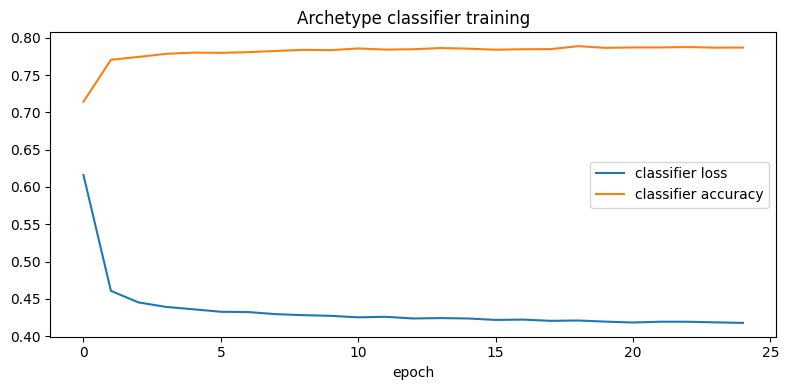

In [11]:
# ============================================================
# Phase 10 — Train archetype classifier
# ============================================================

opt_clf = optim.Adam(CLF.parameters(), lr=1e-3)
ce_loss = nn.CrossEntropyLoss()

clf_epochs = 25
clf_losses = []
clf_accs = []

for ep in range(1, clf_epochs + 1):
    CLF.train()
    total_loss = 0.0
    correct = 0
    total = 0

    for c_batch, _, lb, _ in dataloader:
        c_batch = c_batch.to(DEVICE, non_blocking=True)
        lb = lb.to(DEVICE, non_blocking=True)

        logits = CLF(c_batch)
        loss = ce_loss(logits, lb)

        opt_clf.zero_grad()
        loss.backward()
        opt_clf.step()

        total_loss += loss.item()
        pred = logits.argmax(dim=1)
        correct += (pred == lb).sum().item()
        total += lb.size(0)

    avg_loss = total_loss / max(len(dataloader), 1)
    acc = correct / max(total, 1)
    clf_losses.append(avg_loss)
    clf_accs.append(acc)

    if ep == 1 or ep % 5 == 0 or ep == clf_epochs:
        print(f"Epoch {ep:3d}/{clf_epochs} | loss={avg_loss:.4f} | acc={acc:.3f}")

CLF.eval()
for p in CLF.parameters():
    p.requires_grad_(False)

plt.figure(figsize=(8, 4))
plt.plot(clf_losses, label="classifier loss")
plt.plot(clf_accs, label="classifier accuracy")
plt.title("Archetype classifier training")
plt.xlabel("epoch")
plt.legend()
plt.tight_layout()
plt.show()

In [14]:
from sklearn.metrics import confusion_matrix, classification_report
CLF.eval()
all_preds, all_labels = [], []
with torch.no_grad():
    for c_batch, _, lb, _ in dataloader:
        logits = CLF(c_batch.to(DEVICE))
        preds = logits.argmax(dim=1).cpu()
        all_preds.extend(preds.tolist())
        all_labels.extend(lb.tolist())
print(classification_report(all_labels, all_preds, target_names=["Knight","Berserker","Sniper"]))

              precision    recall  f1-score   support

      Knight       0.75      0.69      0.72      6518
   Berserker       0.75      0.82      0.78      6621
      Sniper       0.94      0.92      0.93      3309

    accuracy                           0.79     16448
   macro avg       0.81      0.81      0.81     16448
weighted avg       0.79      0.79      0.79     16448



Epoch    1/150 | G=0.7058 | D=0.6895 | lr=2.00e-04
Epoch   10/150 | G=0.7148 | D=0.6852 | lr=1.98e-04
Epoch   20/150 | G=0.7231 | D=0.6808 | lr=1.91e-04
Epoch   30/150 | G=0.7429 | D=0.6740 | lr=1.81e-04
Epoch   40/150 | G=0.7523 | D=0.6695 | lr=1.67e-04
Epoch   50/150 | G=0.7605 | D=0.6685 | lr=1.51e-04
Epoch   60/150 | G=0.7665 | D=0.6667 | lr=1.32e-04
Epoch   70/150 | G=0.7695 | D=0.6650 | lr=1.11e-04
Epoch   80/150 | G=0.7670 | D=0.6641 | lr=9.07e-05
Epoch   90/150 | G=0.7715 | D=0.6657 | lr=7.04e-05
Epoch  100/150 | G=0.7746 | D=0.6664 | lr=5.15e-05
Epoch  110/150 | G=0.7696 | D=0.6670 | lr=3.48e-05
Epoch  120/150 | G=0.7696 | D=0.6685 | lr=2.09e-05
Epoch  130/150 | G=0.7690 | D=0.6666 | lr=1.06e-05
Epoch  140/150 | G=0.7661 | D=0.6671 | lr=4.16e-06
Epoch  150/150 | G=0.7663 | D=0.6671 | lr=2.00e-06


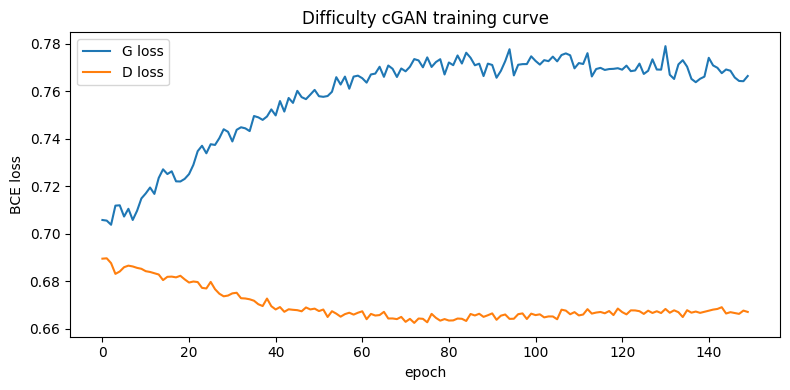

In [12]:
# ============================================================
# Phase 11 — Train difficulty cGAN
# ============================================================

opt_G = optim.Adam(G.parameters(), lr=LR, betas=(0.5, 0.999))
opt_D = optim.Adam(D.parameters(), lr=LR, betas=(0.5, 0.999))

sched_G = optim.lr_scheduler.CosineAnnealingLR(opt_G, T_max=EPOCHS, eta_min=LR / 100)
sched_D = optim.lr_scheduler.CosineAnnealingLR(opt_D, T_max=EPOCHS, eta_min=LR / 100)

bce_loss = nn.BCEWithLogitsLoss()
scaler_G = torch.amp.GradScaler(enabled=USE_AMP)
scaler_D = torch.amp.GradScaler(enabled=USE_AMP)

g_losses = []
d_losses = []

for epoch in range(1, EPOCHS + 1):
    G.train()
    D.train()
    epoch_g = 0.0
    epoch_d = 0.0
    batches = 0

    for c_batch, p_real, _, _ in dataloader:
        c_batch = c_batch.to(DEVICE, non_blocking=True)
        p_real = p_real.to(DEVICE, non_blocking=True)
        bs = c_batch.size(0)

        real_labels = torch.ones(bs, 1, device=DEVICE)
        fake_labels = torch.zeros(bs, 1, device=DEVICE)

        # Discriminator step
        opt_D.zero_grad(set_to_none=True)
        with torch.amp.autocast(device_type=DEVICE.type, enabled=USE_AMP):
            d_real = D(p_real, c_batch)
            loss_d_real = bce_loss(d_real, real_labels)

            z = torch.randn(bs, NOISE_DIM, device=DEVICE)
            p_fake = G(z, c_batch).detach()
            d_fake = D(p_fake, c_batch)
            loss_d_fake = bce_loss(d_fake, fake_labels)

            loss_d = (loss_d_real + loss_d_fake) * 0.5

        scaler_D.scale(loss_d).backward()
        scaler_D.step(opt_D)
        scaler_D.update()

        # Generator step
        opt_G.zero_grad(set_to_none=True)
        with torch.amp.autocast(device_type=DEVICE.type, enabled=USE_AMP):
            z = torch.randn(bs, NOISE_DIM, device=DEVICE)
            p_fake = G(z, c_batch)
            d_out = D(p_fake, c_batch)
            loss_g = bce_loss(d_out, real_labels)

        scaler_G.scale(loss_g).backward()
        scaler_G.step(opt_G)
        scaler_G.update()

        epoch_g += loss_g.item()
        epoch_d += loss_d.item()
        batches += 1

    sched_G.step()
    sched_D.step()

    avg_g = epoch_g / max(batches, 1)
    avg_d = epoch_d / max(batches, 1)
    g_losses.append(avg_g)
    d_losses.append(avg_d)

    if epoch == 1 or epoch % 10 == 0 or epoch == EPOCHS:
        print(f"Epoch {epoch:4d}/{EPOCHS} | G={avg_g:.4f} | D={avg_d:.4f} | lr={sched_G.get_last_lr()[0]:.2e}")

plt.figure(figsize=(8, 4))
plt.plot(g_losses, label="G loss")
plt.plot(d_losses, label="D loss")
plt.title("Difficulty cGAN training curve")
plt.xlabel("epoch")
plt.ylabel("BCE loss")
plt.legend()
plt.tight_layout()
plt.show()

Epoch   1/75 | MSE=0.01694 | lr=1.00e-03
Epoch  10/75 | MSE=0.00569 | lr=9.57e-04
Epoch  20/75 | MSE=0.00564 | lr=8.36e-04
Epoch  30/75 | MSE=0.00562 | lr=6.58e-04
Epoch  40/75 | MSE=0.00560 | lr=4.53e-04
Epoch  50/75 | MSE=0.00559 | lr=2.57e-04
Epoch  60/75 | MSE=0.00558 | lr=1.05e-04
Epoch  70/75 | MSE=0.00557 | lr=2.08e-05
Epoch  75/75 | MSE=0.00557 | lr=1.00e-05


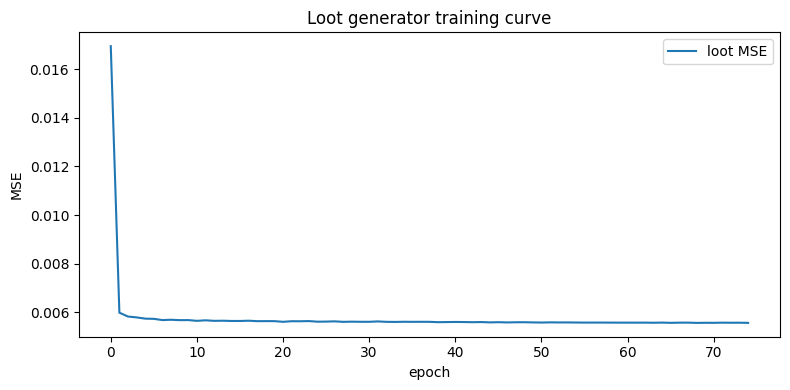

In [13]:
# ============================================================
# Phase 12 — Train loot generator
# ============================================================

opt_lg = optim.Adam(LG.parameters(), lr=1e-3)
sched_lg = optim.lr_scheduler.CosineAnnealingLR(opt_lg, T_max=max(40, EPOCHS // 2), eta_min=1e-5)
mse_loss = nn.MSELoss()
scaler_lg = torch.amp.GradScaler(enabled=USE_AMP)

loot_epochs = max(40, EPOCHS // 2)
loot_losses = []

LG.train()
for ep in range(1, loot_epochs + 1):
    ep_loss = 0.0
    batches = 0

    for c_batch, _, _, loot_batch in dataloader:
        c_batch = c_batch.to(DEVICE, non_blocking=True)
        loot_batch = loot_batch.to(DEVICE, non_blocking=True)
        bs = c_batch.size(0)

        with torch.no_grad():
            c_soft = torch.softmax(CLF(c_batch), dim=1)

        opt_lg.zero_grad(set_to_none=True)
        with torch.amp.autocast(device_type=DEVICE.type, enabled=USE_AMP):
            z = torch.randn(bs, 8, device=DEVICE)
            pred = LG(z, c_soft)
            loss = mse_loss(pred, loot_batch)

        scaler_lg.scale(loss).backward()
        scaler_lg.step(opt_lg)
        scaler_lg.update()

        ep_loss += loss.item()
        batches += 1

    sched_lg.step()
    avg_loss = ep_loss / max(batches, 1)
    loot_losses.append(avg_loss)

    if ep == 1 or ep % 10 == 0 or ep == loot_epochs:
        print(f"Epoch {ep:3d}/{loot_epochs} | MSE={avg_loss:.5f} | lr={sched_lg.get_last_lr()[0]:.2e}")

plt.figure(figsize=(8, 4))
plt.plot(loot_losses, label="loot MSE")
plt.title("Loot generator training curve")
plt.xlabel("epoch")
plt.ylabel("MSE")
plt.legend()
plt.tight_layout()
plt.show()

In [ ]:
# ============================================================
# Phase 13 — Generation sanity check before saving
# ============================================================

PARAM_NAMES = ["enemy_hp_mult", "enemy_dmg_mult", "enemy_speed_mult", "spawn_count_norm"]
FEATURE_NAMES = ["melee_ratio", "magic_ratio", "hpk_melee", "hpk_magic", "dmg_ratio", "death_rate"]

G.eval()
D.eval()
CLF.eval()
LG.eval()

sample_idx = np.random.choice(len(C), size=min(8, len(C)), replace=False)
sample_c = C[sample_idx].to(DEVICE)

with torch.no_grad():
    z = torch.randn(sample_c.size(0), NOISE_DIM, device=DEVICE)
    p_norm = G(z, sample_c)

pm = torch.tensor(par_means, dtype=torch.float32, device=DEVICE)
ps = torch.tensor(par_stds, dtype=torch.float32, device=DEVICE)
p_raw = (p_norm * ps + pm).cpu().numpy()

preview = pd.DataFrame(p_raw, columns=PARAM_NAMES)
preview["spawn_count"] = np.round(2 + np.clip(preview["spawn_count_norm"], 0, 1) * 8).astype(int)
preview["enemy_hp_mult"] = preview["enemy_hp_mult"].clip(0.45, 3.5).round(3)
preview["enemy_dmg_mult"] = preview["enemy_dmg_mult"].clip(0.35, 2.8).round(3)
preview["enemy_speed_mult"] = preview["enemy_speed_mult"].clip(0.70, 2.0).round(3)
display(preview[["enemy_hp_mult", "enemy_dmg_mult", "enemy_speed_mult", "spawn_count"]])

with torch.no_grad():
    c_soft = torch.softmax(CLF(sample_c), dim=1)
    loot_weights = LG(torch.randn(sample_c.size(0), 8, device=DEVICE), c_soft).cpu().numpy()

loot_preview = pd.DataFrame(loot_weights, columns=["weapon_w", "spell_w", "armor_w", "boots_w"])
display(loot_preview.round(3))

In [ ]:
# ============================================================
# Phase 14 — Export artifacts
# ============================================================

OUT_DIR.mkdir(parents=True, exist_ok=True)

# Unwrap compiled modules if torch.compile was used.
def state_dict_unwrapped(model):
    return getattr(model, "_orig_mod", model).state_dict()

torch.save(state_dict_unwrapped(G), OUT_DIR / "generator.pt")
torch.save(state_dict_unwrapped(LG), OUT_DIR / "loot_generator.pt")
torch.save(state_dict_unwrapped(CLF), OUT_DIR / "classifier.pt")

scaler = {
    "cond_means": cond_means,
    "cond_stds": cond_stds,
    "par_means": par_means,
    "par_stds": par_stds,
    "noise_dim": NOISE_DIM,
    "feature_names": FEATURE_NAMES,
    "param_names": PARAM_NAMES,
    "archetype_names": ARCHETYPE_NAMES,
}

with open(OUT_DIR / "scaler.json", "w", encoding="utf-8") as f:
    json.dump(scaler, f, indent=2)

plt.figure(figsize=(8, 4))
plt.plot(g_losses, label="G loss")
plt.plot(d_losses, label="D loss")
plt.title("Difficulty cGAN training curve")
plt.xlabel("epoch")
plt.ylabel("BCE loss")
plt.legend()
plt.tight_layout()
plt.savefig(OUT_DIR / "training_curve.png", dpi=120)
plt.show()

print("Saved artifacts:")
for p in ["generator.pt", "loot_generator.pt", "classifier.pt", "scaler.json", "training_curve.png"]:
    print(" -", OUT_DIR / p)

In [ ]:
# ============================================================
# Phase 15 — Generate model_runtime.py
# ============================================================

MODEL_RUNTIME_TEMPLATE = r'''
import json
import os
import torch
import torch.nn as nn

COND_DIM = 6
PARAM_DIM = 4
ARCH_DIM = 3
LOOT_DIM = 4


def _best_device() -> torch.device:
    if torch.cuda.is_available():
        return torch.device("cuda")
    if getattr(torch.backends, "mps", None) and torch.backends.mps.is_available():
        return torch.device("mps")
    return torch.device("cpu")


class Generator(nn.Module):
    def __init__(self, noise_dim, cond_dim=COND_DIM, param_dim=PARAM_DIM):
        super().__init__()
        inp = noise_dim + cond_dim
        self.net = nn.Sequential(
            nn.Linear(inp, 64), nn.LeakyReLU(0.2),
            nn.Linear(64, 128), nn.LeakyReLU(0.2),
            nn.Linear(128, 64), nn.LeakyReLU(0.2),
            nn.Linear(64, param_dim),
        )
    def forward(self, z, c):
        return self.net(torch.cat([z, c], dim=1))


class LootGenerator(nn.Module):
    def __init__(self, noise_dim=8, cond_dim=ARCH_DIM, out_dim=LOOT_DIM):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(noise_dim + cond_dim, 32), nn.ReLU(),
            nn.Linear(32, 32), nn.ReLU(),
            nn.Linear(32, out_dim),
            nn.Sigmoid(),
        )
    def forward(self, z, c):
        return self.net(torch.cat([z, c], dim=1))


class ArchetypeClassifier(nn.Module):
    def __init__(self, cond_dim=COND_DIM):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(cond_dim, 32), nn.ReLU(),
            nn.Linear(32, 16), nn.ReLU(),
            nn.Linear(16, ARCH_DIM),
        )
    def forward(self, x):
        return self.net(x)


class LoadedModels:
    def __init__(self, generator, loot_generator, classifier, scaler, device):
        self.generator = generator
        self.loot_generator = loot_generator
        self.classifier = classifier
        self.scaler = scaler
        self.device = device

    @classmethod
    def load(cls, model_dir: str):
        device = _best_device()
        scaler_path = os.path.join(model_dir, "scaler.json")
        gen_path = os.path.join(model_dir, "generator.pt")
        loot_path = os.path.join(model_dir, "loot_generator.pt")
        clf_path = os.path.join(model_dir, "classifier.pt")

        with open(scaler_path, encoding="utf-8") as f:
            scaler = json.load(f)

        noise_dim = scaler["noise_dim"]

        gen = Generator(noise_dim=noise_dim)
        gen.load_state_dict(torch.load(gen_path, map_location="cpu"))
        gen.to(device).eval()

        loot_gen = LootGenerator()
        loot_gen.load_state_dict(torch.load(loot_path, map_location="cpu"))
        loot_gen.to(device).eval()

        clf = ArchetypeClassifier()
        clf.load_state_dict(torch.load(clf_path, map_location="cpu"))
        clf.to(device).eval()

        return cls(gen, loot_gen, clf, scaler, device)

    def _normalise_features(self, features: torch.Tensor) -> torch.Tensor:
        sc = self.scaler
        cm = torch.tensor(sc["cond_means"], dtype=torch.float32, device=self.device)
        cs = torch.tensor(sc["cond_stds"], dtype=torch.float32, device=self.device)
        return (features.to(self.device) - cm) / cs

    def generate(self, features: torch.Tensor) -> dict:
        c = self._normalise_features(features)
        noise_dim = self.scaler["noise_dim"]
        z = torch.randn(features.size(0), noise_dim, device=self.device)

        with torch.no_grad():
            p_norm = self.generator(z, c)

        pm = torch.tensor(self.scaler["par_means"], dtype=torch.float32, device=self.device)
        ps = torch.tensor(self.scaler["par_stds"], dtype=torch.float32, device=self.device)
        p = (p_norm * ps + pm).detach().cpu()

        results = []
        for row in p:
            hp_mult = max(0.45, min(3.5, float(row[0])))
            dmg_mult = max(0.35, min(2.8, float(row[1])))
            speed_mult = max(0.70, min(2.0, float(row[2])))
            spawn_norm = max(0.0, min(1.0, float(row[3])))
            spawn_n = max(2, min(10, int(round(2 + spawn_norm * 8))))

            results.append({
                "enemy_hp_mult": round(hp_mult, 3),
                "enemy_dmg_mult": round(dmg_mult, 3),
                "enemy_speed_mult": round(speed_mult, 3),
                "spawn_count": spawn_n,
            })

        return results[0] if len(results) == 1 else results

    def generate_loot_bias(self, features: torch.Tensor) -> list:
        c_norm = self._normalise_features(features)
        with torch.no_grad():
            c_soft = torch.softmax(self.classifier(c_norm), dim=1)
            z = torch.randn(features.size(0), 8, device=self.device)
            weights = self.loot_generator(z, c_soft).detach().cpu()

        out = weights.tolist()
        return out[0] if len(out) == 1 else out
'''

runtime_path = OUT_DIR / "model_runtime.py"
with open(runtime_path, "w", encoding="utf-8") as f:
    f.write(MODEL_RUNTIME_TEMPLATE)

print("Runtime module saved:", runtime_path)

In [ ]:
# ============================================================
# Phase 16 — Runtime smoke test
# ============================================================

import importlib.util

runtime_path = OUT_DIR / "model_runtime.py"
spec = importlib.util.spec_from_file_location("model_runtime", runtime_path)
model_runtime = importlib.util.module_from_spec(spec)
spec.loader.exec_module(model_runtime)

loaded = model_runtime.LoadedModels.load(str(OUT_DIR))

# Raw, non-normalized CombatMetrics examples:
# [melee_ratio, magic_ratio, hpk_melee, hpk_magic, dmg_ratio, death_rate]
test_features = torch.tensor([
    [0.85, 0.15, 3.0, 4.0, 0.75, 0.1],  # Knight-ish
    [0.90, 0.10, 5.0, 5.0, 1.8, 0.8],   # Berserker-ish
    [0.10, 0.90, 5.0, 3.0, 0.5, 0.1],   # Spell Sniper-ish
], dtype=torch.float32)

print("Generated difficulty:")
for item in loaded.generate(test_features):
    print(item)

print("
Generated loot bias [weapon, spell, armor, boots]:")
for item in loaded.generate_loot_bias(test_features):
    print([round(x, 3) for x in item])

## Notes for thesis use

This notebook is structured for debugging and evidence generation. The most useful sections for screenshots/results are:

1. **Raw CSV audit** — proves the dataset schema and row count.
2. **Dataset distribution audit** — shows real/bot balance and bot-style distribution.
3. **Label derivation** — shows how many labels came from `run_id` and how many used heuristic fallback.
4. **Classifier training curve** — validates archetype separation.
5. **cGAN training curve** — validates adversarial training behavior.
6. **Runtime smoke test** — proves exported artifacts can be loaded and used.

For final academic validation, do not claim the bot-heavy dataset proves player experience improvement. Use it as the training/prototype dataset, then validate with real user sessions.